In [1]:
from oidic import reconstruct
import matplotlib.pyplot as plt
import numpy as np
from oidic_simulator import coherent_oidic_image_model as coherent

In [2]:
def simulate_phase_square(pixel_size, chip_size, wl, w, n1, n2, \
                          full_thick, sample_thick):
    """
    Build a simulated phase object in a square shape, 
    consisting of a sample and background
   
    Parameters
    ----------
    pixel_size : float
        Effective pixel size of camera chip in nm
    chip_size : int
        How many pixels on the camera chip
    wl : float
        Wavelength of emitted light in nm   
    w: float
        Width in x and y direction of the sample in nm
    n1: float
        Background refractive index
    n2: float
        Sample refractive index
    full_thick: float
        Full object thickness in nm
    sample_thick: float 
        Sample thickness in nm
    
    Returns
    -------
    sm : np.array
        Phase shift of light passing through the object
    bg: np.array
        Phase shift of light passing through only the background
    Plot the sample and the background
    """
    
    duration = pixel_size * chip_size
    N = chip_size
    sample_rate = N / duration
    x = np.linspace(-duration/2, duration/2, N)
    y = x
    X, Y = np.meshgrid(x, y)
    
    sm = np.ones_like(X)*n1*2*np.pi*full_thick/wl
    sm[(Y>=-w)&(Y<=w)&(X>=-w)&(X<=w)] *= n2/n1*sample_thick/full_thick+\
                                            (1-sample_thick/full_thick)
    bg = np.ones_like(X)*n1*2*np.pi*full_thick/wl
    
    fig = plt.figure(figsize=(20,10))
    plt.subplot(121)
    plt.imshow(sm, cmap=plt.cm.gray)
    plt.colorbar()
    plt.title('Sample')
    plt.subplot(122)
    plt.imshow(bg, cmap=plt.cm.gray)
    plt.colorbar()
    plt.title('Background')
    plt.show()
    
    return sm, bg

In [3]:
# Sampling parameters
pixel_size = 64.5 
chip_size = 500   

# Simulated object parameters
n2 = 1.57
n1 = 1.52
w = 6000
full_thick = 800
sample_thick = 500

# Imaging parameters
wl = 530                           # wavelength [nm]
NA = 1.35                           # numerical aperture
n = 1.0                              # refractive index surrounding the point source
tau1 = 3*np.pi/2                 # shear angle 1 [rad]
tau2 = np.pi                         # shear angle 2 [rad]
d = 172                           # shear distance [nm]
bias = 0.15                     # bias in [wavelength]

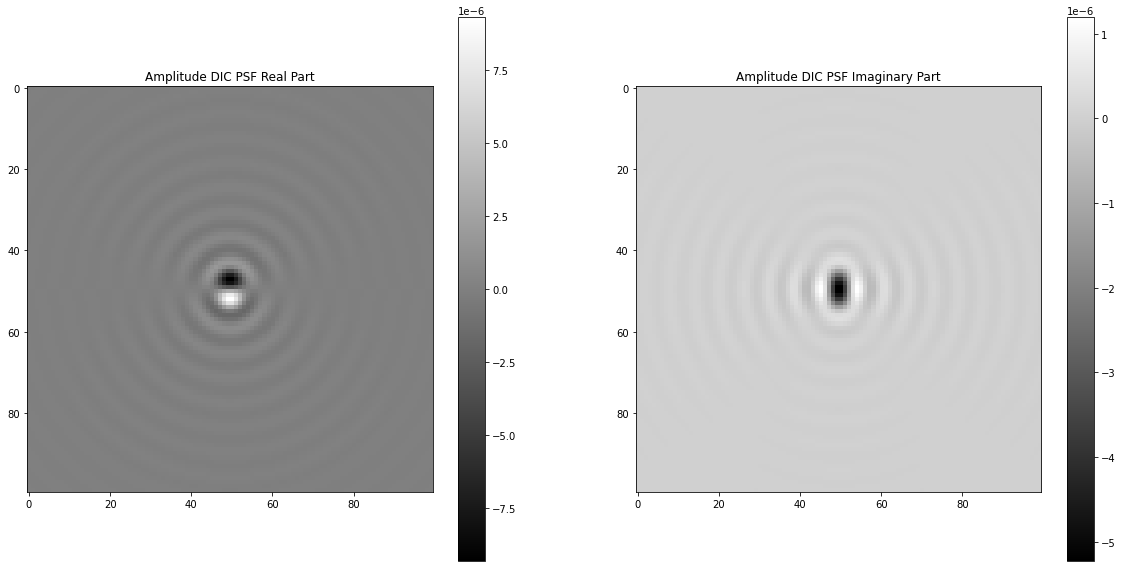

In [4]:
psf_real, psf_imag = coherent.plot_amplitude_dic_psf_2d(pixel_size, chip_size,\
                              wl, NA, n, np.sqrt(2)*d, tau1, bias)

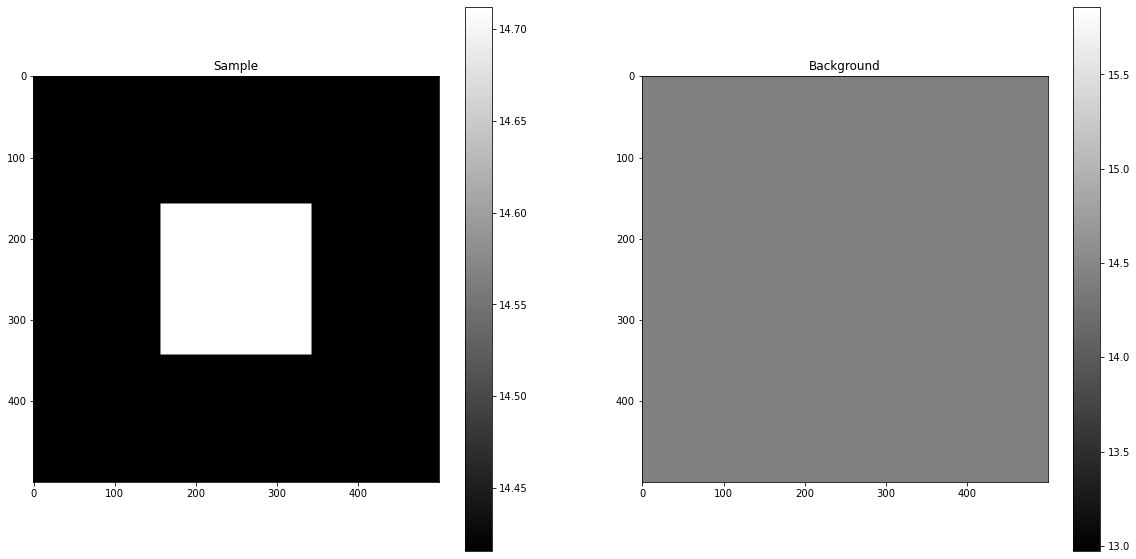

In [5]:
sm, bg = simulate_phase_square(pixel_size, chip_size, wl, w, n1, n2, \
                          full_thick, sample_thick)

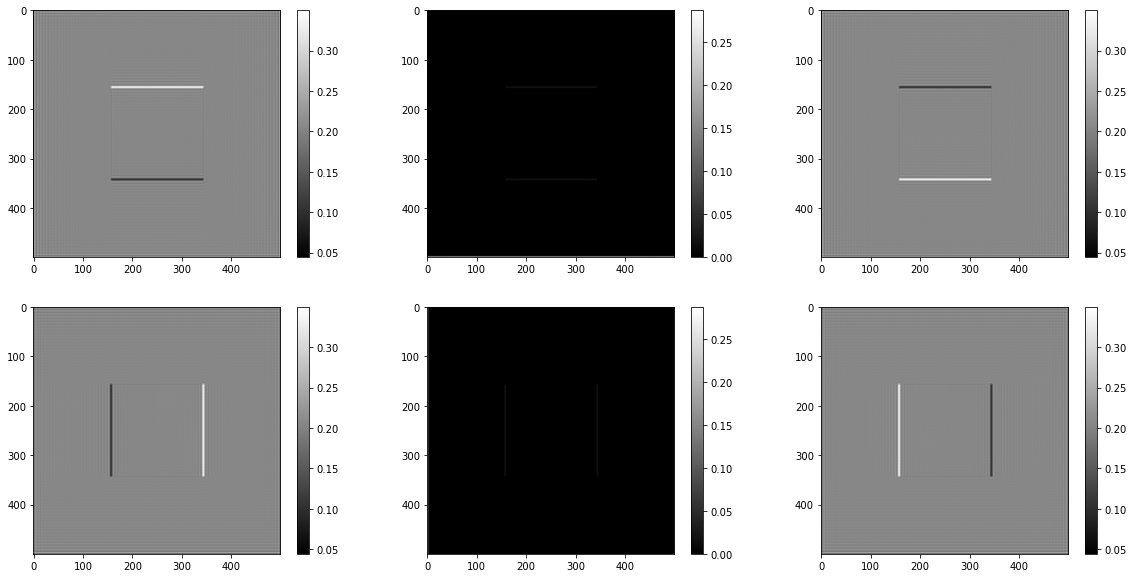

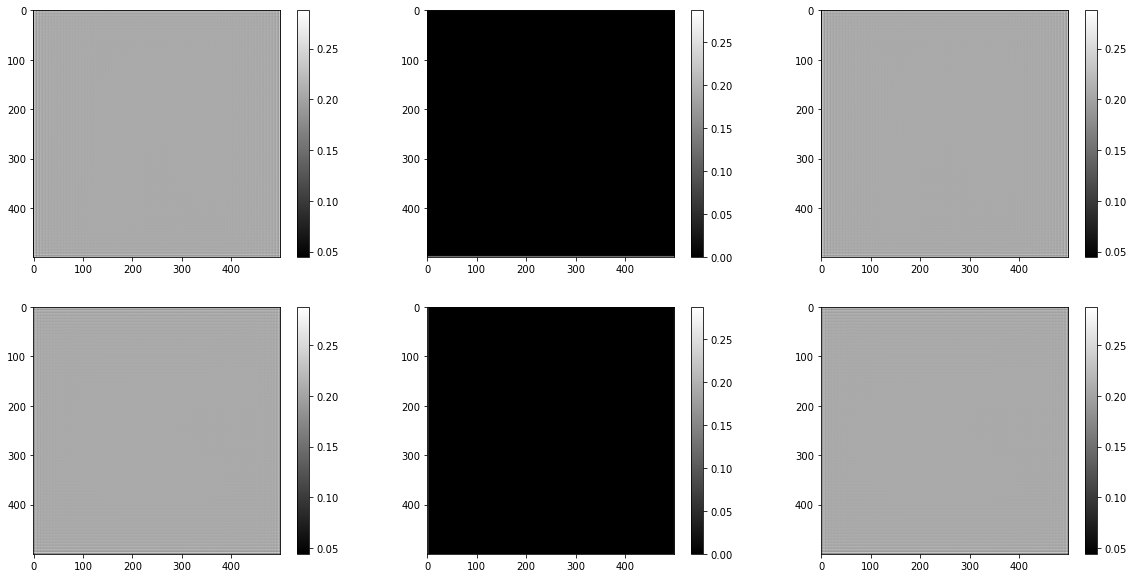

In [6]:
image_stack = coherent.coherent_image_model(sm, pixel_size, chip_size, \
                                            wl, NA, n, d, tau1, tau2, bias)
bg_image_stack = coherent.coherent_image_model(bg, pixel_size, chip_size, \
                                               wl, NA, n, d, tau1, tau2, bias)

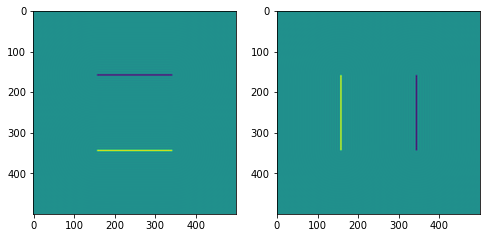

In [7]:
n_frames = 6
A0, A1 = reconstruct.calculate_A(image_stack, wl, bias*wl, n_frames)
bg_A0, bg_A1 = reconstruct.calculate_A(bg_image_stack, wl, bias*wl, n_frames)
A0 -= bg_A0
A1 -= bg_A1

fig, axs = plt.subplots(1, 2, figsize=(8,16))
axs[0].imshow(A0.squeeze())
axs[1].imshow(A1.squeeze())
plt.show()

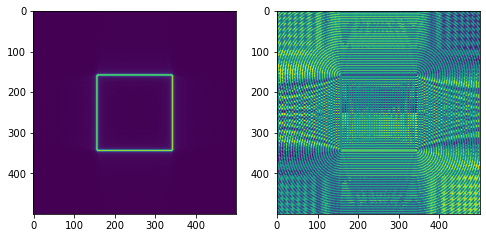

In [8]:
mag, azim = reconstruct.calculate_magnitude_gradient(A0, A1, wl, d)
fig, axs = plt.subplots(1, 2, figsize=(8,16))
axs[0].imshow(mag.squeeze())
axs[1].imshow(azim.squeeze())

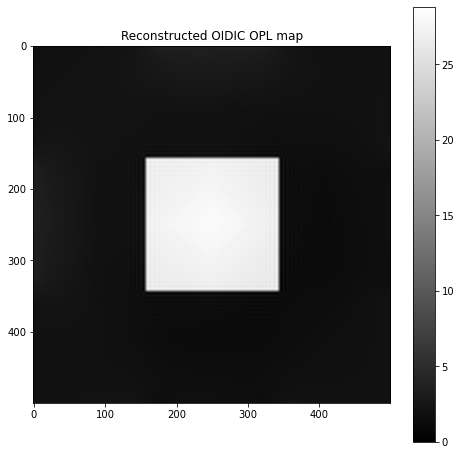

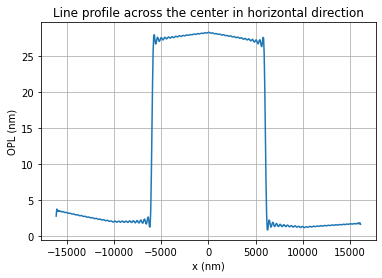

In [9]:
opl = coherent.simulate_reconstruct(pixel_size, chip_size, image_stack, wl, \
                              bias*wl, d, NA,\
                              bg_image_stack, n_frames, 'integrate',\
                             shear_bias=0)

In [10]:
print(opl.squeeze()[int(chip_size/2),int(chip_size/2)],(n2-n1)*sample_thick)

28.347967467515097 25.00000000000002
